# Final Project FP-7:  Machine Learning Challenge

<br>
<br>


___

# <span style="color:blue">Analysis of Factors Influencing Human Losses from Earthquakes</span>


### Overview:

* **Name**:  <span style="color:blue">Polina Kozlova</span>
* **Student number**:  <span style="color:blue">B990374732</span>

<br>

### Purpose:

* <span style="color:blue">The purpose of this project is to identify the main factors that contribute to human losses caused by earthquakes.</span>
* <span style="color:blue">The key dependent variable (DV) is Death Description:

0 - None <br>
1 - Few (≈1 to 50 people) <br>
2 - Some (≈51 to 100 people) <br>
3 - Many (≈101 to 1000 people) <br>
4 - Very Many (≈1001 or more people)

</span>

* <span style="color:blue">Key independent variables (IVs) include Mag (magnitude), Focal Depth (km) (depth of earthquake focus in kilometers), Latitude (geographic latitude), Longitude (geographic longitude).</span>
* <span style="color:blue">This dataset contains 2207 cases.</span>


<br>

### Dataset source:

The data come from the NOAA Significant Earthquake Database provided by the National Geophysical Data Center (NGDC).
The dataset is publicly available through the NOAA Hazards Viewer and contains detailed records of earthquake events, including date, magnitude, location, focal depth, and reported human impacts.
The data are available for download [here](https://www.ngdc.noaa.gov/hazel/view/hazards/earthquake/event-data?minDeathsAmountOrder=0&minDamageAmountOrder=0&minDeathsAmountOrderTotal=0)

(https://www.ngdc.noaa.gov/hazel/view/hazards/earthquake/event-data?minDeathsAmountOrder=0&minDamageAmountOrder=0&minDeathsAmountOrderTotal=0)

<br>
<br>
<br>
<br>

___

## Descriptive Statistics



In [1]:
%%capture
%run descriptive.ipynb

In [ ]:
display_central_tendency_table(num=1)
display_dispersion_table(num=2)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,Death Description,Mag,Focal Depth,Lat,Long
mean,1.61,6.42,30.35,18.833,35.773
median,1.00,6.40,20.00,25.324,52.034
mode,1.00,6.10,10.00,36.000,-76.500


<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Dispersion summary statistics.</span></p>

,Death Description,Mag,Focal Depth,Lat,Long
st.dev.,1.03,0.96,38.79,21.290,80.728
min,1.00,2.10,0.00,-54.000,-178.252
max,4.00,9.50,651.00,60.908,178.291
range,3.00,7.40,651.00,114.908,356.543
25th,1.00,5.80,10.00,1.100,-66.803
75th,2.00,7.10,33.00,36.802,102.741
IQR,1.00,1.30,23.00,35.702,169.544


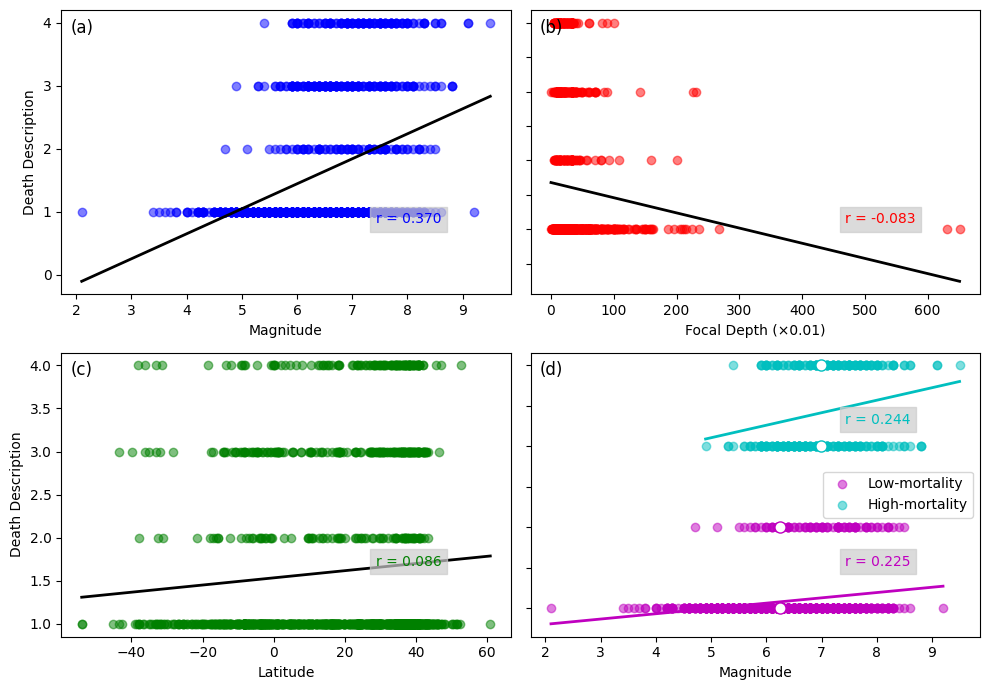

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations among earthquake variables</span></p><br><br>

In [ ]:
plot_descriptive()

In [2]:
%%capture
%run classical.ipynb


---
### Hypothesis 1:
do shallow earthquakes (focal depth ≤ 70 km) produce higher fatality levels than deep earthquakes (> 70 km) within the strongest magnitude category (Mag ≥ 8.0)?

H₀: The mean log₁₀(Deaths + 1) is equal for shallow and deep earthquakes.

H₁: Shallow earthquakes have a higher mean log₁₀(Deaths + 1) than deep earthquakes.  
(One-sided Welch's t-test)

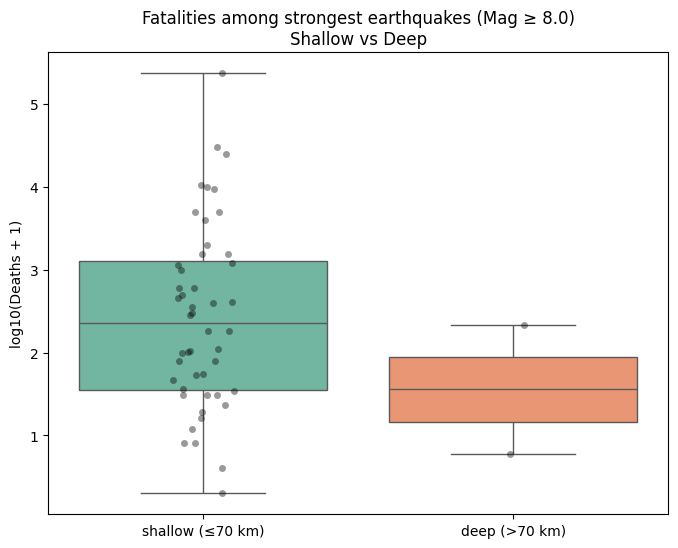

In [ ]:
plot_h1()


### Result:
Shallow earthquakes have a higher average fatality level compared to deep earthquakes.  

Conclusion: even among the strongest earthquakes, shallow earthquakes (focal depth ≤ 70 km) produce higher fatality levels than deep earthquakes (> 70 km)

---
### Hypothesis 2:

Do earthquakes with extreme shaking levels (MMI ≥ IX) produce higher fatalities than those with moderate shaking (MMI ≤ VIII)?

H₀: The mean log₁₀(Deaths + 1) is the same for MMI ≥ IX and MMI ≤ VIII.

H₁: Earthquakes with MMI ≥ IX have higher mean log₁₀(Deaths + 1).  





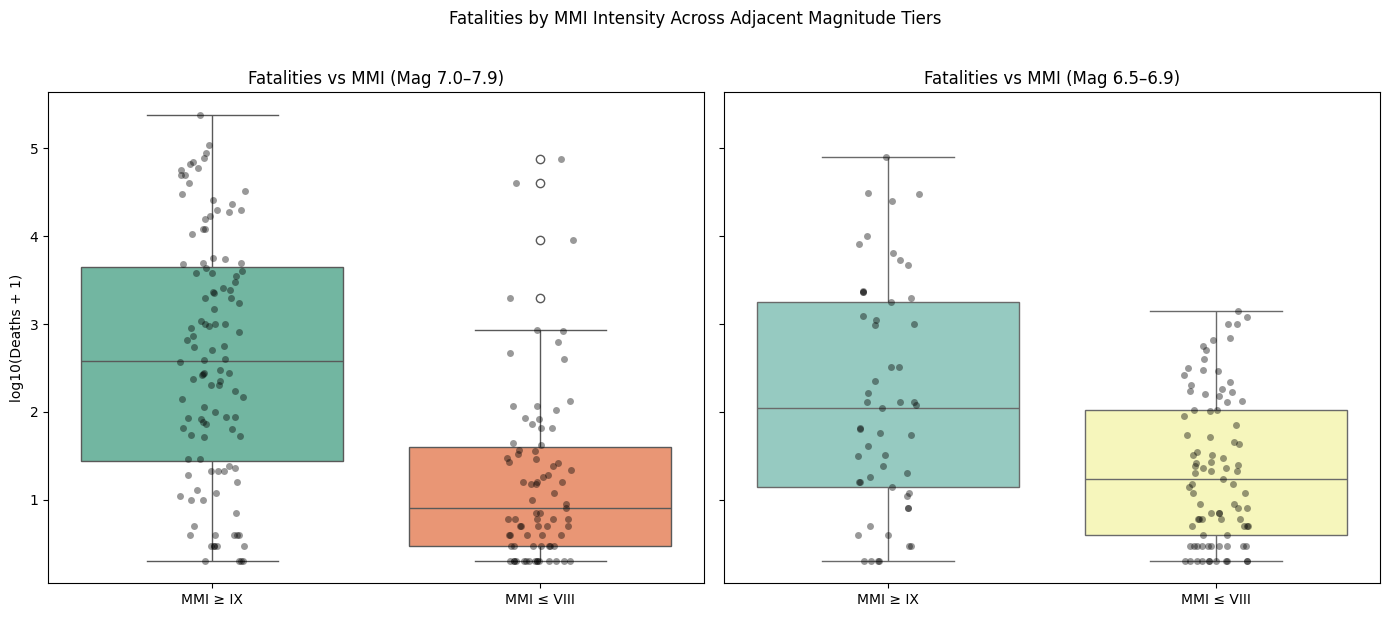

In [ ]:
plot_h2()

### Result: Magnitude 7.0–7.9:
Earthquakes with MMI ≥ IX show higher fatality levels compared to MMI ≤ VIII within this tier.  

### Result: Magnitude 6.5–6.9:
The pattern persists in the second tier: MMI ≥ IX events exhibit higher fatalities.  



-------------

# Final Project FP-6:  Machine Learning

<br>
<br>

In [3]:
%%capture
%run machine.py

## Modeling setup

**Target:** `log10(Deaths + 1)`

**Models:** Ridge regression pipeline with imputation + scaling.

**Validation:**
  - Cross-validation (KFold) for Result 1
  - Held-out test split for Result 2


### Model validation

Model performance was evaluated using 5-fold cross-validation to compare model specifications and estimate RMSE across multiple data splits.  


Тhe final model was assessed on a held-out test set, providing an out of sample evaluation of predictive performance (RMSE, MAE, R²).


In [ ]:
run_all_machine_analyses("Earthquakes.csv")

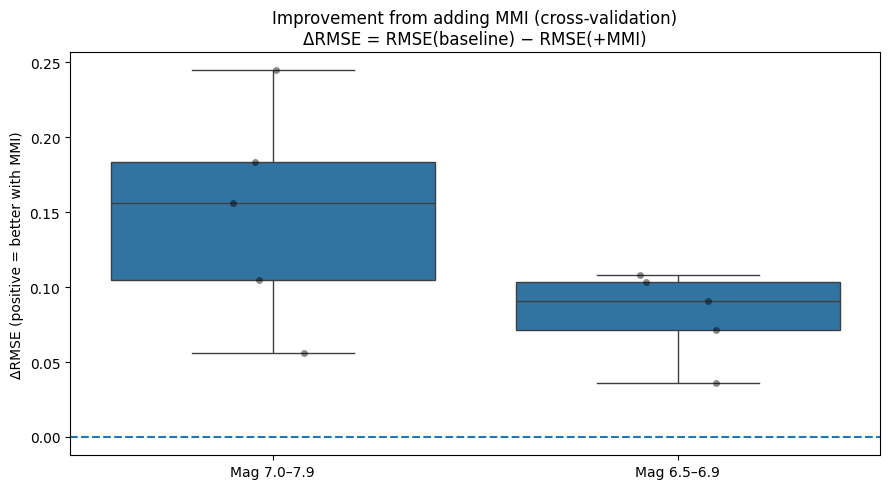

ΔRMSE summary (positive means MMI helps):
                 mean       std  count
tier                                  
Mag 6.5–6.9  0.081785  0.029373      5
Mag 7.0–7.9  0.148866  0.072460      5


In [ ]:
plot_main_result_1_delta_rmse()


### Result 1: Adding MMI improves predictive accuracy (cross-validation)

We compare Ridge models without MMI versus with MMI across two adjacent magnitude tiers:
- Mag 7.0–7.9
- Mag 6.5–6.9

The evaluation metric is ΔRMSE = RMSE(baseline) − RMSE(+MMI), computed across cross-validation folds.
Positive ΔRMSE values indicate improved predictive performance when MMI is included.

**Results:** ΔRMSE is positive in both tiers (mean ΔRMSE ≈ 0.08–0.15), indicating that MMI adds predictive value beyond magnitude and depth.  
The improvement is notably larger in the higher-magnitude tier (Mag 7.0–7.9), suggesting that surface shaking intensity becomes increasingly informative for stronger earthquakes.


-----------

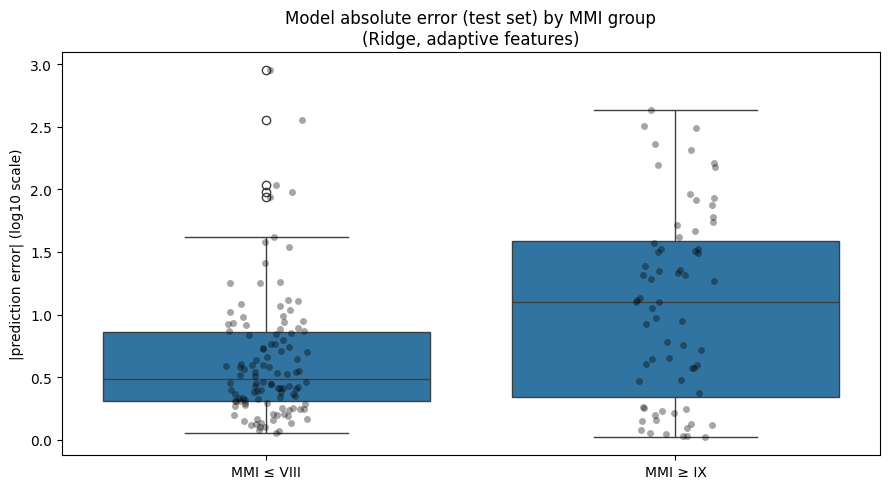

Result 2 meta:
  grouping mode: fixed_IX_threshold
  features used: ['Mag', 'Focal Depth (km)', 'MMI Int']
  group counts: {'MMI ≤ VIII': 454, 'MMI ≥ IX': 273}
  rows used: 727 | test size: 182

Abs error by MMI group (test set):
                mean    median  count
mmi_group                            
MMI ≤ VIII  0.637475  0.487603    114
MMI ≥ IX    1.068841  1.099303     68

Held-out test metrics: {'rmse': 1.0244630806275343, 'mae': 0.7986447054483015, 'r2': 0.3255488929613124}


In [ ]:
plot_main_result_2_error_by_mmi()

### Result 2: Prediction errors are larger for high-intensity earthquakes (test set)

Using a held-out test set, we compare the model’s absolute prediction error between:
- MMI ≤ VIII
- MMI ≥ IX

The average absolute error is substantially higher for MMI ≥ IX events (mean ≈ 1.07) than forMMI ≤ VIII events (mean ≈ 0.64).  
This pattern holds for both the mean and median error values.

**Interpretation:** even when MMI is included as a predictor, earthquakes with extreme shaking intensity exhibit greater prediction uncertainty.  
This suggests that the most destructive events are influenced by additional, unobserved factors (e.g., population exposure, infrastructure vulnerability), making their human impact inherently harder to predict.


-----------
# Final Project FP-7:  Machine Learning Challenge

<br>
<br>


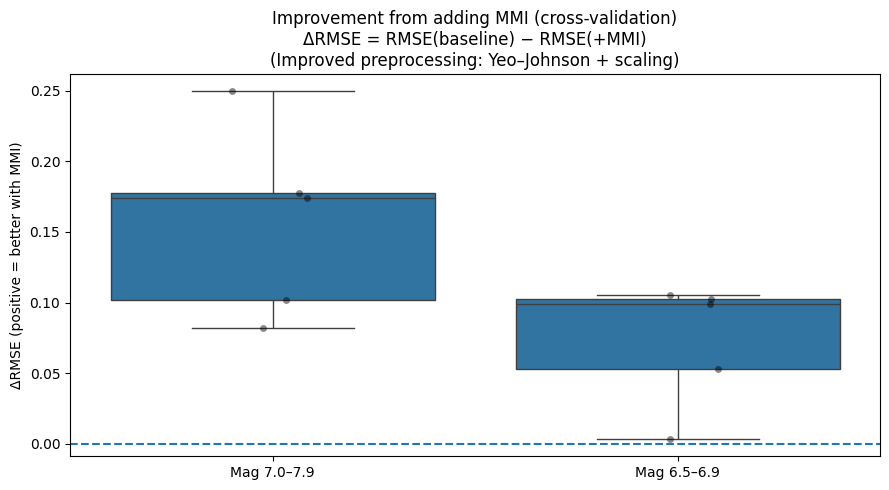

ΔRMSE summary (positive means MMI helps):
                 mean       std  count
tier                                  
Mag 6.5–6.9  0.072792  0.044363      5
Mag 7.0–7.9  0.157111  0.066948      5


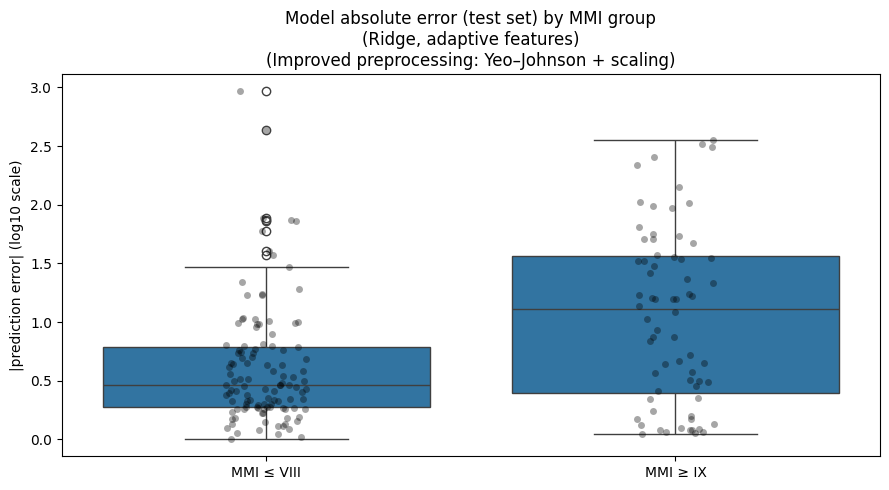

Result 2 meta:
  grouping mode: fixed_IX_threshold
  features used: ['Mag', 'Focal Depth (km)', 'MMI Int']
  group counts: {'MMI ≤ VIII': 454, 'MMI ≥ IX': 273}
  rows used: 727 | test size: 182

Abs error by MMI group (test set):
                mean    median  count
mmi_group                            
MMI ≤ VIII  0.620306  0.463101    114
MMI ≥ IX    1.051771  1.108211     68

Held-out test metrics: {'rmse': 1.0112378436483396, 'mae': 0.7815126571893362, 'r2': 0.34285005542932756}


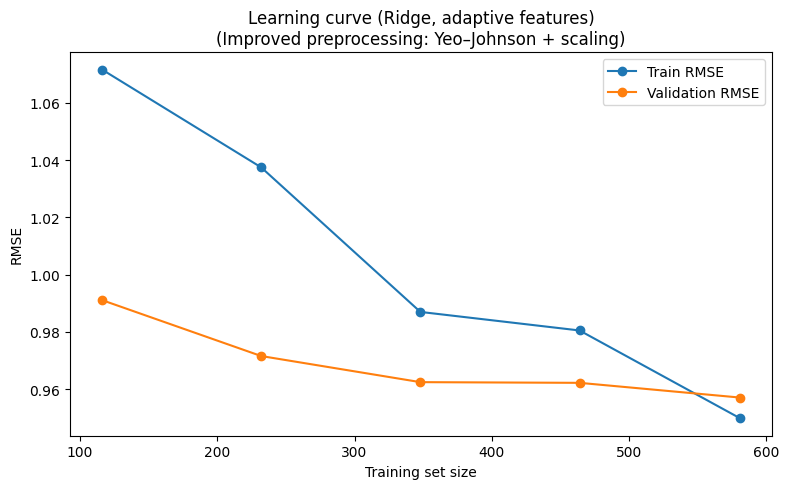

<Figure size 640x480 with 0 Axes>

In [7]:
%run improved.py


## Comparison with FP-6

### Result 1 (ΔRMSE from adding MMI).
In FP-6, adding MMI led to positive ΔRMSE values in both magnitude tiers. After improving the preprocessing with a Yeo–Johnson power transformation, ΔRMSE remains positive across all folds. For the 7.0–7.9 magnitude range, the mean ΔRMSE slightly increases (to about 0.157), while for 6.5–6.9 it decreases slightly (to about 0.073). Overall, the conclusion that MMI improves predictive performance is unchanged.


____________


### Result 2 (test-set performance).
The improved preprocessing results in lower test-set errors without changing the dataset or the model. RMSE decreases from about 1.024 to 1.011, MAE decreases from about 0.799 to 0.782, and R² increases from about 0.33 to 0.34. Mean absolute errors decrease for both MMI groups, although high-MMI earthquakes remain harder to predict.

## Conclusion

The results show that improving the preprocessing alone leads to modest but consistent gains in model performance. MMI provides additional predictive value, and high-intensity earthquakes are more difficult to predict. However, with better preprocessing, the model generalizes slightly better to unseen data, as reflected by lower test errors and a higher R². This confirms that the observed improvements are driven by data preparation rather than changes in the dataset or the learning algorithm.